未发现 /home/aiuser/work/final/w3b_model.json, 开始三阶段从零训练
  训练 2019-08-01 ~ 2023-06-26   验证 2023-07-01 ~ 2024-12-31(早停)
[prep] 交易日 1371 (2019-05-23 ~ 2025-01-10)  PIT 池 1,371,000 条
  [train] 2019-05-23~2019-11-22  累计 5,977,872 行  +19s
  [train] 2019-11-23~2020-05-22  累计 11,672,832 行  +34s
  [train] 2020-05-23~2020-11-22  累计 17,510,592 行  +50s
  [train] 2020-11-23~2021-05-22  累计 23,254,704 行  +67s
  [train] 2021-05-23~2021-11-22  累计 29,144,592 行  +86s
  [train] 2021-11-23~2022-05-22  累计 34,796,688 行  +104s
  [train] 2022-05-23~2022-11-22  累计 40,785,792 行  +125s
  [train] 2022-11-23~2023-05-22  累计 46,488,720 行  +146s
  [train] 2023-05-23~2023-07-08  累计 48,020,688 行  +153s
  [train] 1849 票 / 1,000,431 块  +153s
  [train] 日历一致 ✅ 1003 天全部建出块
[bycat] 常数指纹(流式量应跨环境逐位一致; 分位量允许 <1% 的采样差):
  mu_pc=2.505580 sd_pc=1.146294 lo_pc=-1.509956 hi_pc=2.341639
  wlo=-0.105361 whi=0.182321 sig_struct=0.025218
  mu_v3=[9.713606, 12.243363, 3.31532] sd_v3=[1.809586, 1.830728, 1.250939]
  mu_ov=9.285771 sd_ov=2.27

时段,IC
2024-01-15~2024-02-08,0.0152
2024-09-24~2024-10-08,0.0706

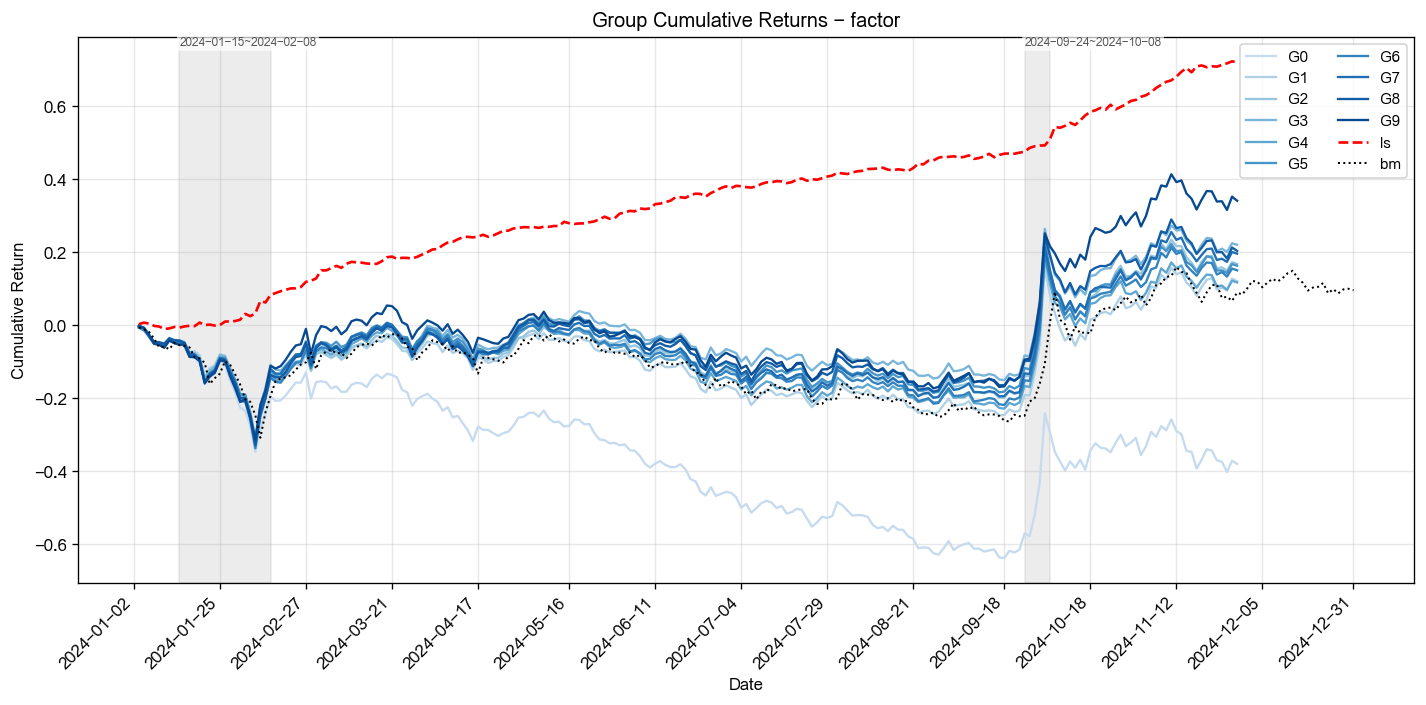
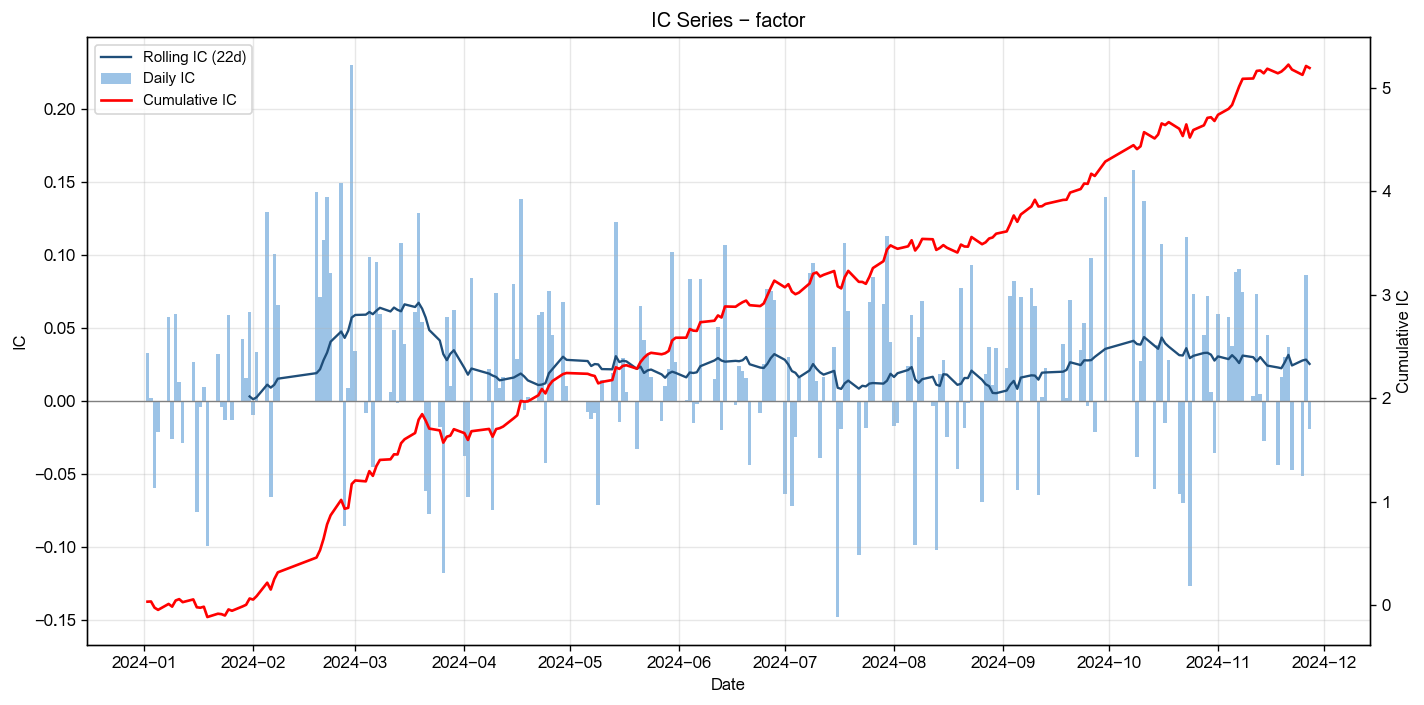
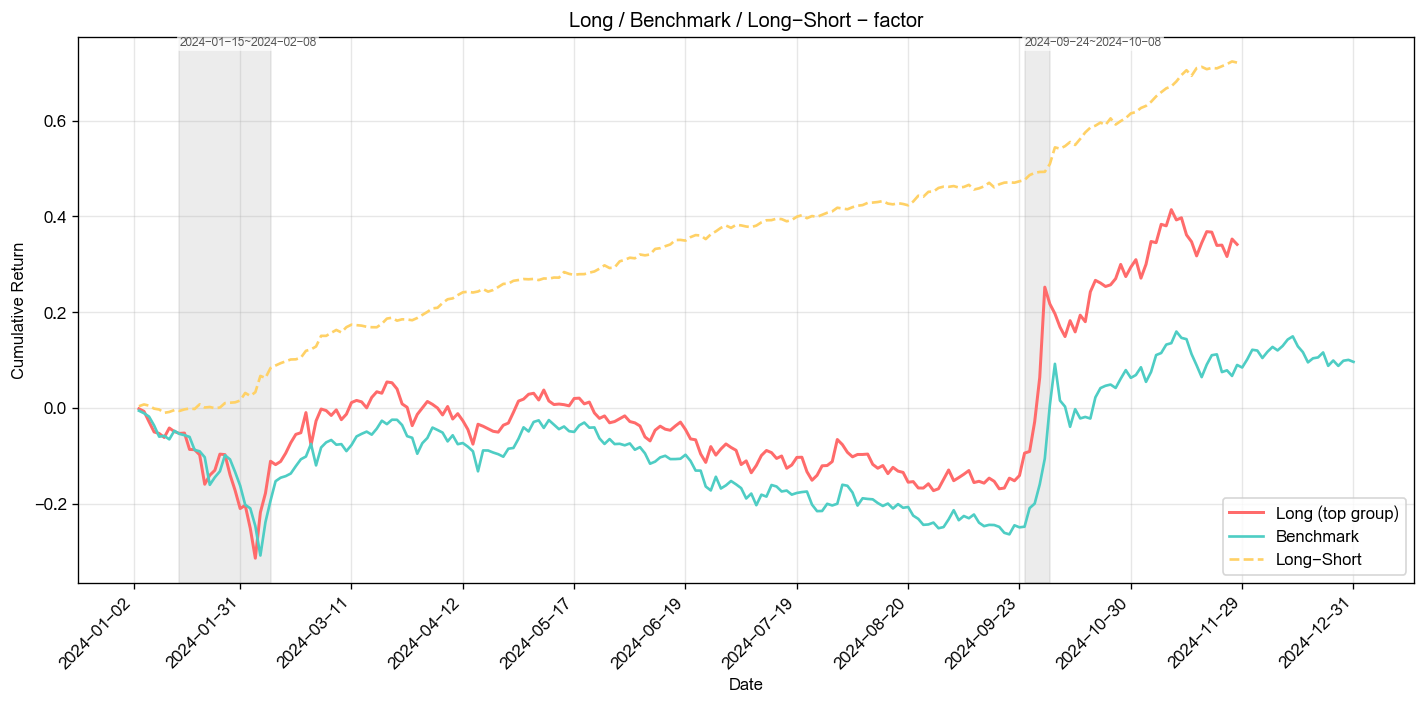
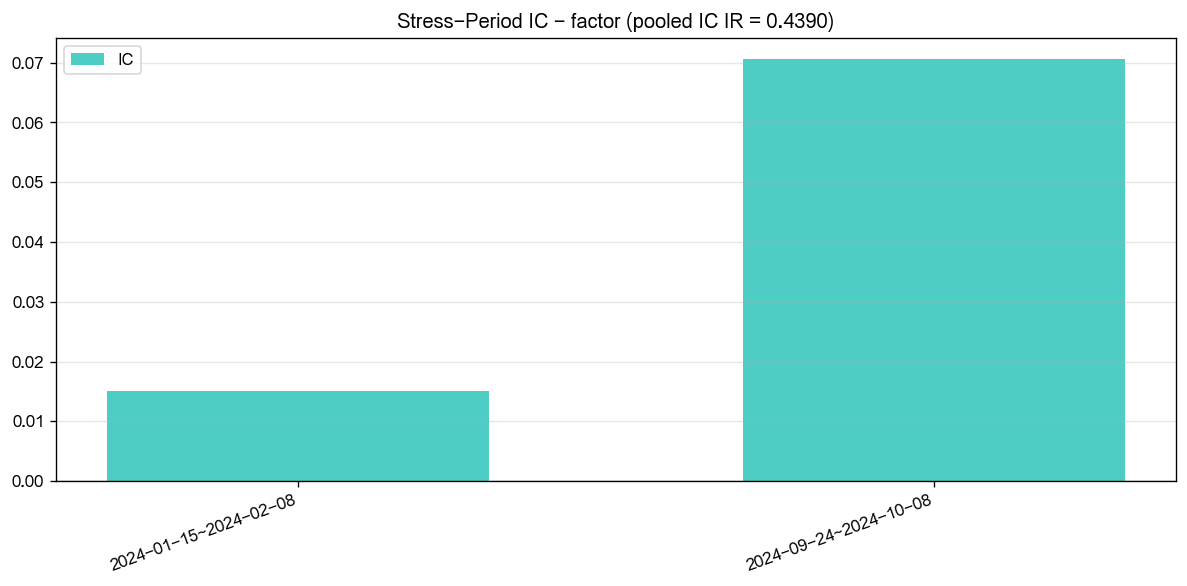
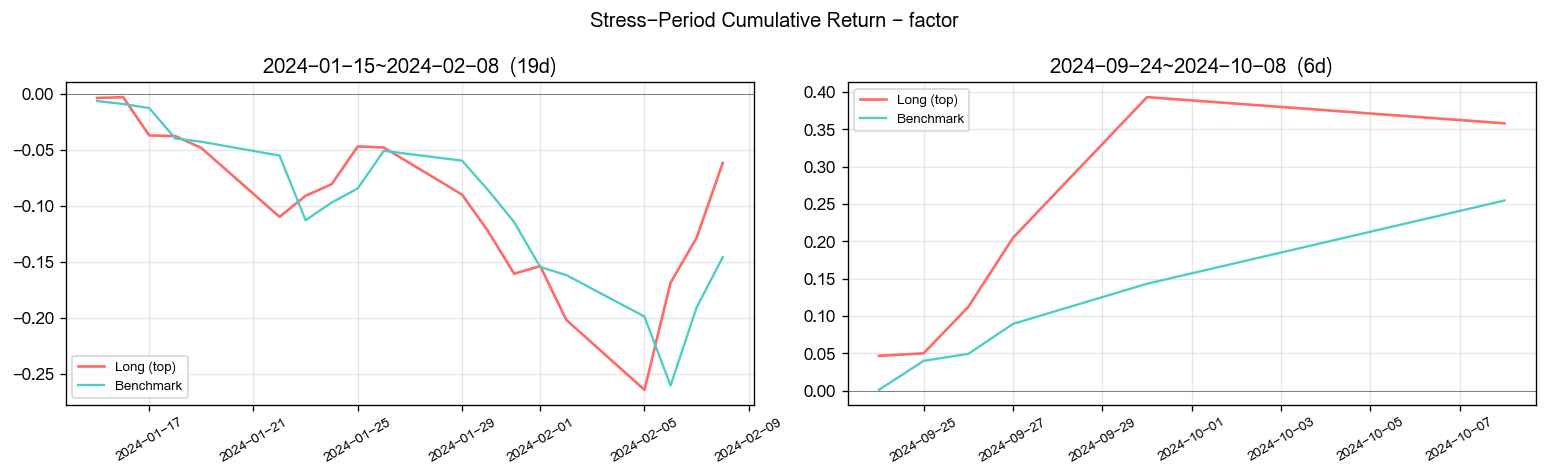

[2026-08-05 21:23:05] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-08-05 21:23:05] [warning  ] 返回的Outputs实例(size=35378892) 大于 64K, 将不会被缓存
[2026-08-05 21:23:05] [info     ] bigalpha_eval.v4 运行完成 [18.372s].


In [1]:
"""BigAlpha 2026 · 最终提交(W3b)—— 执行入口

模型 / 数据 / 训练 / 推理的定义都在 **w3b_model.py**(单一事实来源), 本 notebook 只负责执行。

    公榜: 平台只替换 datasources / start_date / end_date 并调用 `main`,
          用随本 notebook 上传的 `w3b_model.json` 做推理, **不训练**。
    私榜: 平台用本代码在隔离环境**从零重训**, 故 `train_and_save` 必须可运行、结果可复现。

提交清单
    w3b_submit.ipynb   本文件
    w3b_model.py       定义与配置
    w3b_model.json     训练产出的权重(首次在训练环境跑一次下面的 __main__ 即可生成)

模型
    x(48根5m bar × 38字段)
      ├─[CSFront 前置截面] 当日全票互看(top-k16) → 修正 x
      ├─[主干] PLE → DenoiseBlock(48根bar互看) → 双向GRU → raw(128)
      ├─[DayAxis 日间轴]  raw + Wout(GRU_h16(过去29天的日嵌入))
      └─[CSLayer 后置截面] 当日全票互看(top-k16) → proj → LN → mlp → score

    三阶段: N05(主干+加噪, 从零) → W1(主干+csf, 从零) → W3b(冻住 W1, 日间轴+截面同步训)

⚠️ 训练/验证区间都写死在 w3b_model.py(训 2019-08~2023-06-26、验 2023-07~2024-12),
   不用传入的 start/end 训练(规则 A15)。这个划分与 3-ablation/batch30-1 的实验**逐字一致** ——
   实验的所有结论都建立在它上面。
   平台注入的 start/end 是**测试区间**, 在平台内部、我们看不见。
"""
import os

from w3b_model import (
    MODEL_PATH, TABLE_KEY, BAR_TABLE,
    TRAIN_START, TRAIN_END, VAL_START, VAL_END,
    train_and_save, predict,
)


def main(datasources, start_date, end_date):
    """平台入口: 加载 w3b_model.json, 在样本外测试区间打分, **不训练**。

    返回 ['date','instrument','score'] —— 已左连 PIT 全票池、缺失填当日截面均值,
    保证是完整面板(规则 A22),且每日缺失率会打印出来核对 40% 红线(规则 A16)。
    """
    return predict(datasources, start_date, end_date)


if __name__ == "__main__":
    from bigmodule import M

    datasources = {TABLE_KEY: BAR_TABLE}

    # ---------- 权重: 没有就训一次, 有就直接用 ----------
    if not os.path.exists(MODEL_PATH):
        print(f"未发现 {MODEL_PATH}, 开始三阶段从零训练")
        print(f"  训练 {TRAIN_START} ~ {TRAIN_END}   验证 {VAL_START} ~ {VAL_END}(早停)")
        train_and_save(datasources)
    else:
        print(f"已存在 {MODEL_PATH}, 跳过训练, 直接推理")

    # ---------- 推理(本地用一小段模拟「平台注入的测试集区间」)----------
    # ⚠️ 这段 2024 与**验证集重叠** ⇒ 这里打印的评估不是干净的样本外, 只用来验证
    #    "推理链路能跑通、输出是完整面板"。真正的样本外成绩看平台榜。
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())

    # ---------- 评估(分数经风格剔除后等价于每日单因子)----------
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)
